In [33]:
# import libraries
import glob
import os
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [34]:
# prepare data
madrid_2017 = pd.read_csv('data/madrid_2017.csv')
stations = pd.read_csv('data/stations.csv')


In [35]:

madrid_2017.head()

,date,BEN,CH4,CO,EBE,NMHC,NO,NO_2,NOx,O_3,PM10,PM25,SO_2,TCH,TOL,station
0,2017-06-01 01:00:00,NaN,NaN,0.3,NaN,NaN,4.0,38.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,28079004
1,2017-06-01 01:00:00,0.6,NaN,0.3,0.4,0.08,3.0,39.0,NaN,71.0,22.0,9.0,7.0,1.4,2.9,28079008
2,2017-06-01 01:00:00,0.2,NaN,NaN,0.1,NaN,1.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,0.9,28079011
3,2017-06-01 01:00:00,NaN,NaN,0.2,NaN,NaN,1.0,9.0,NaN,91.0,NaN,NaN,NaN,NaN,NaN,28079016
4,2017-06-01 01:00:00,NaN,NaN,NaN,NaN,NaN,1.0,19.0,NaN,69.0,NaN,NaN,2.0,NaN,NaN,28079017


In [36]:
stations.head()

,id,name,address,lon,lat,elevation
0,28079004,Pza. de España,Plaza de España,-3.712247,40.423853,635
1,28079008,Escuelas Aguirre,Entre C/ Alcalá y C/ O’ Donell,-3.682319,40.421564,670
2,28079011,Avda. Ramón y Cajal,Avda. Ramón y Cajal esq. C/ Príncipe de Vergara,-3.677356,40.451475,708
3,28079016,Arturo Soria,C/ Arturo Soria esq. C/ Vizconde de los Asilos,-3.639233,40.440047,693
4,28079017,Villaverde,C/. Juan Peñalver,-3.713322,40.347139,604


In [37]:
# format data
madrid_2017['date'] = pd.to_datetime(madrid_2017['date'])

In [38]:
# calculate mean NO_2 for each station
station_mean = madrid_2017.groupby('station')['NO_2'].mean().reset_index()
station_mean.head()

,station,NO_2
0,28079004,49.428080
1,28079008,61.867318
2,28079011,45.717346
3,28079016,41.710264
4,28079017,48.607767


In [39]:
# merge 2017 data with station metadata
madrid_2017_station = station_mean.merge(stations, left_on='station', right_on='id')
madrid_2017_station.head()

,station,NO_2,id,name,address,lon,lat,elevation
0,28079004,49.428080,28079004,Pza. de España,Plaza de España,-3.712247,40.423853,635
1,28079008,61.867318,28079008,Escuelas Aguirre,Entre C/ Alcalá y C/ O’ Donell,-3.682319,40.421564,670
2,28079011,45.717346,28079011,Avda. Ramón y Cajal,Avda. Ramón y Cajal esq. C/ Príncipe de Vergara,-3.677356,40.451475,708
3,28079016,41.710264,28079016,Arturo Soria,C/ Arturo Soria esq. C/ Vizconde de los Asilos,-3.639233,40.440047,693
4,28079017,48.607767,28079017,Villaverde,C/. Juan Peñalver,-3.713322,40.347139,604


In [40]:
fig = px.scatter_map(
    madrid_2017_station,
    lat="lat",
    lon="lon",
    color="NO_2",
    color_continuous_scale="Blues",
    range_color=[0, 75],
    hover_name="name",
    size="NO_2",
    size_max=15,
    hover_data={
        "lat": False,
        "lon": False,
        "NO_2": ":.2f",
    },
    zoom=10,
    center={"lat": 40.435, "lon": -3.69},
    map_style="carto-positron",
    title="<b>Madrid Air Quality</b><br><sup>Continuous NO₂ Concentration (µg/m³)</sup>",
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0},
                  coloraxis_colorbar=dict(title="NO₂ (µg/m³)",yanchor="top",
                                          y=1, ticks="outside",
                                          thickness=15,  len=0.4),
    font=dict(family="Arial", size=12))
fig.show()

In [41]:
#Q3
files = glob.glob(os.path.join("data", "madrid_*.csv"))

# Union all files
df_all = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)
df_all.columns = df_all.columns.str.lower()

# date fields
df_all["date"] = pd.to_datetime(df_all["date"], errors="coerce")
df_all["year"] = df_all["date"].dt.year

# left join
df_all = df_all.merge(
    stations,
    left_on="station",
    right_on="id",
    how="left"
)

df_all.head()

,date,ben,co,ebe,mxy,nmhc,no_2,nox,oxy,o_3,...,pm25,no,ch4,year,id,name,address,lon,lat,elevation
0,2001-08-01 01:00:00,NaN,0.37,NaN,NaN,NaN,58.400002,87.150002,NaN,34.529999,...,NaN,NaN,NaN,2001,NaN,NaN,NaN,NaN,NaN,NaN
1,2001-08-01 01:00:00,1.5,0.34,1.49,4.1,0.07,56.250000,75.169998,2.11,42.160000,...,NaN,NaN,NaN,2001,28079035.0,Pza. del Carmen,Plaza del Carmen esq. Tres Cruces.,-3.703172,40.419208,659.0
2,2001-08-01 01:00:00,NaN,0.28,NaN,NaN,NaN,50.660000,61.380001,NaN,46.310001,...,NaN,NaN,NaN,2001,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-08-01 01:00:00,NaN,0.47,NaN,NaN,NaN,69.790001,73.449997,NaN,40.650002,...,NaN,NaN,NaN,2001,28079004.0,Pza. de España,Plaza de España,-3.712247,40.423853,635.0
4,2001-08-01 01:00:00,NaN,0.39,NaN,NaN,NaN,22.830000,24.799999,NaN,66.309998,...,NaN,NaN,NaN,2001,28079039.0,Barrio del Pilar,Avd. Betanzos esq. C/ Monforte de Lemos,-3.711542,40.478228,674.0


In [42]:
# settings
BASE_YEAR = 2009
COMPARE_YEAR = 2017
MIN_OBS = 100

MIN_STATIONS_PER_POLLUTANT = 4
MIN_POLLUTANTS_PER_STATION = 4


In [43]:
# choose what pollutants to compare
non_pollutant_cols = [
    "date", "year", "station", "id", "name", "address",
    "lon", "lat", "elevation"
]

pollutants = [
    col for col in df_all.columns
    if col not in non_pollutant_cols
]

df = df_all[df_all["year"].isin([BASE_YEAR, COMPARE_YEAR])].copy()

df.head()

,date,ben,co,ebe,mxy,nmhc,no_2,nox,oxy,o_3,...,pm25,no,ch4,year,id,name,address,lon,lat,elevation
1824695,2009-01-01,NaN,0.29,NaN,NaN,NaN,42.250000,53.549999,NaN,20.690001,...,9.44,NaN,NaN,2009,NaN,NaN,NaN,NaN,NaN,NaN
1824696,2009-01-01,NaN,0.43,NaN,NaN,NaN,56.360001,73.529999,NaN,15.580000,...,NaN,NaN,NaN,2009,NaN,NaN,NaN,NaN,NaN,NaN
1824697,2009-01-01,NaN,0.40,NaN,NaN,NaN,65.029999,164.699997,NaN,26.400000,...,NaN,NaN,NaN,2009,28079004.0,Pza. de España,Plaza de España,-3.712247,40.423853,635.0
1824698,2009-01-01,NaN,0.23,NaN,NaN,NaN,42.070000,45.580002,NaN,23.740000,...,NaN,NaN,NaN,2009,28079039.0,Barrio del Pilar,Avd. Betanzos esq. C/ Monforte de Lemos,-3.711542,40.478228,674.0
1824699,2009-01-01,0.89,0.35,0.77,1.21,0.12,44.750000,65.580002,0.77,18.379999,...,9.55,NaN,NaN,2009,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# change per pollutant
results = []

for pollutant in pollutants:
    temp = (
        df
        .dropna(subset=[pollutant])
        .groupby(["station", "name", "year"])
        .agg(
            avg_value=(pollutant, "mean"),
            n_obs=(pollutant, "count")
        )
        .reset_index()
    )

    temp = temp[temp["n_obs"] >= MIN_OBS]

    wide = temp.pivot_table(
        index=["station", "name"],
        columns="year",
        values="avg_value"
    ).reset_index()

    if BASE_YEAR in wide.columns and COMPARE_YEAR in wide.columns:
        wide = wide.dropna(subset=[BASE_YEAR, COMPARE_YEAR])

        if len(wide) > 0:
            wide["pollutant"] = pollutant.upper()
            wide["change_pct"] = (
                (wide[COMPARE_YEAR] - wide[BASE_YEAR]) / wide[BASE_YEAR]
            ) * 100

            results.append(
                wide[["station", "name", "pollutant", "change_pct"]]
            )

change_df = pd.concat(results, ignore_index=True)

change_df.head()

year,station,name,pollutant,change_pct
0,28079008,Escuelas Aguirre,BEN,57.432109
1,28079011,Avda. Ramón y Cajal,BEN,83.639839
2,28079018,Farolillo,BEN,-78.468883
3,28079024,Casa de Campo,BEN,-46.457554
4,28079038,Cuatro Caminos,BEN,-69.253864


In [45]:
# heatmap
heatmap_data = change_df.pivot_table(
    index="name",
    columns="pollutant",
    values="change_pct"
)
heatmap_data.head()

pollutant,BEN,CO,EBE,NMHC,NOX,NO_2,O_3,PM10,PM25,SO_2,TCH,TOL
name,,,,,,,,,,,,
Arturo Soria,NaN,6.852003,NaN,NaN,76.359746,-3.361401,1.048724,NaN,NaN,NaN,NaN,NaN
Avda. Ramón y Cajal,83.639839,NaN,-66.767493,NaN,56.688632,-16.909405,NaN,NaN,NaN,NaN,NaN,-1.675084
Barajas Pueblo,NaN,NaN,NaN,NaN,58.954455,-11.014322,NaN,NaN,NaN,NaN,NaN,NaN
Barrio del Pilar,NaN,50.142878,NaN,NaN,129.042055,-0.349436,-3.787758,NaN,NaN,NaN,NaN,NaN
Casa de Campo,-46.457554,-38.799765,-77.504360,-65.677846,62.404730,-23.967952,-1.334397,-5.904401,3.403924,-58.022405,-9.391538,-10.568377


In [46]:
# total change
heatmap_data["Total"] = heatmap_data.mean(axis=1)

# top/bottom performers
top_worse = heatmap_data.sort_values("Total", ascending=False).head(8)
top_better = heatmap_data.sort_values("Total", ascending=True).head(8)

heatmap_data = pd.concat([top_worse, top_better])
heatmap_data = heatmap_data[~heatmap_data.index.duplicated()]
heatmap_data = heatmap_data.sort_values("Total", ascending=False)


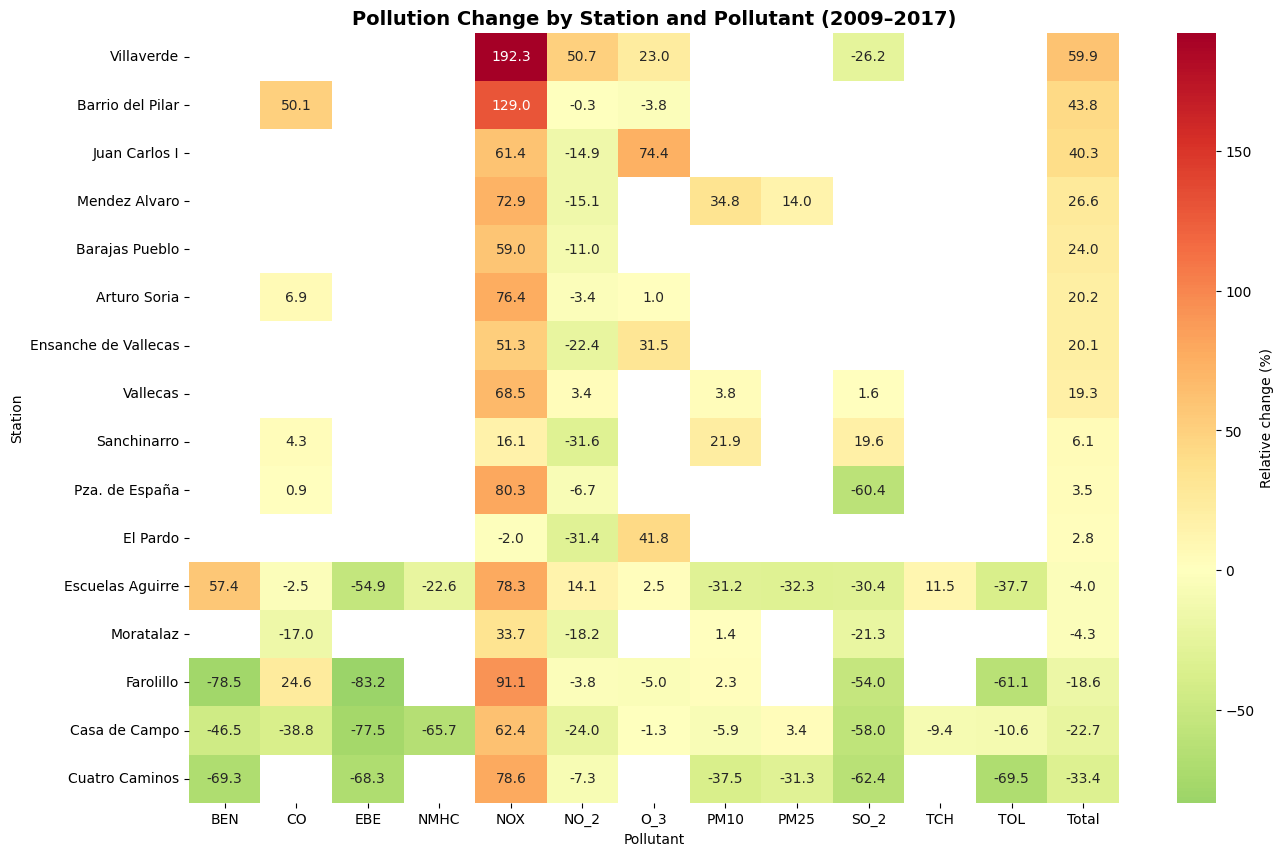

In [47]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    center=0,
    cbar_kws={"label": "Relative change (%)"}
)

plt.title(
    f"Pollution Change by Station and Pollutant ({BASE_YEAR}–{COMPARE_YEAR})",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Pollutant")
plt.ylabel("Station")
plt.show()


In [48]:
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# build monthly city-wide averages from the hourly data
madrid_2017['month'] = madrid_2017['date'].dt.month
monthly = (
    madrid_2017.groupby('month')[['NO_2', 'O_3']]
    .mean()
    .reset_index()
)

def savefig(fname):
    plt.savefig(fname, dpi=150, bbox_inches='tight')

Policy 4/4 – NO₂ vs O₃ annual trend 2001–2018


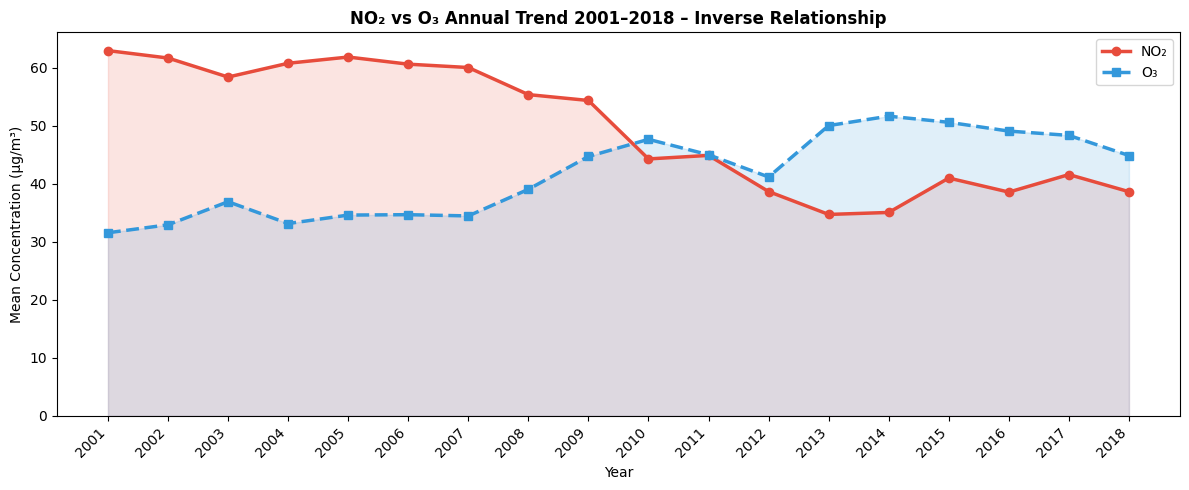

In [49]:
# Q4. NO₂ vs O₃ long-term annual trend (2001–2018)
print("Policy 4/4 – NO₂ vs O₃ annual trend 2001–2018")

years = range(2001, 2019)
records = []
for yr in years:
    df = pd.read_csv(f"data/madrid_{yr}.csv")
    records.append({
        "year": yr,
        "NO_2": df["NO_2"].mean(),
        "O_3":  df["O_3"].mean(),
    })
annual = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual["year"], annual["NO_2"], color="#e74c3c", linewidth=2.5,
        marker="o", label="NO₂")
ax.fill_between(annual["year"], annual["NO_2"], alpha=0.15, color="#e74c3c")
ax.plot(annual["year"], annual["O_3"],  color="#3498db", linewidth=2.5,
        marker="s", linestyle="--", label="O₃")
ax.fill_between(annual["year"], annual["O_3"], alpha=0.15, color="#3498db")
ax.set_ylim(bottom=0)
ax.set_xticks(list(years))
ax.set_xticklabels(list(years), rotation=45, ha="right")
ax.set_ylabel("Mean Concentration (µg/m³)")
ax.set_xlabel("Year")
ax.legend(loc="upper right", fontsize=10)
ax.set_title("NO₂ vs O₃ Annual Trend 2001–2018 – Inverse Relationship",
             fontsize=12, weight="bold")
plt.tight_layout()
savefig("Q4_pollutants_2001_2018_trend.png")